# 01 · Rainfall data — M30 Manzanares

**Reference:** Navas et al. (2024) · *Ingeniería del Agua* · DOI 10.4995/ia.2024.22293

The input data are **hourly rainfall series** from **17 gauging stations** (CHT + MAPA networks) covering mainly 2002–2021. A total of **1,761 precipitation events** were identified using a threshold of Pmax ≥ 5 mm. Each event is described by four parameters at each gauge: **Pmax** (peak intensity), **Pmed** (mean intensity), **Duration**, and **Type** (hyetograph shape).  

> The data available in this repository are the **synthetic selected events** (output of the MaxDiss step). The original hourly series are not available here.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'm30_manzanares'

EVENTS_DIR   = DATA_ROOT / 'events'
RESULTS_DIR  = DATA_ROOT / 'results'
STATIONS_DIR = DATA_ROOT / 'stations'

print('DATA_ROOT:', DATA_ROOT)

T_VALS   = [2, 5, 10, 20, 50, 100, 500]
N_STAT   = 17
LAM      = 5.17    # Poisson rate (events/year)
XS_PT    = 6262    # Toledo Bridge cross-section
XS_R9    = 4112    # Weir No.9 cross-section


DATA_ROOT: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/m30_manzanares


## 1. Gauge network

Stations: 17
                  X        Y     Z
P_27         423801  4512050  1072
E_21         433268  4488018   632
P_62         438125  4473980   593
E_15         430627  4506997   897
AR17         457037  4472337   541
AR18         452950  4464075   553
AR19         420729  4482914   613
E_16         411468  4487914   834
E_22         453963  4461119   500
MC02         455075  4477700   566
P_26         435400  4522050  1279
P_31         403150  4495050  1135
PN23         425100  4529200  1218
M01__Mapama  457867  4473610   604
M02__Mapama  457693  4462410   537
M03__Mapama  446220  4432570   487
M05__Mapama  452366  4453800   512


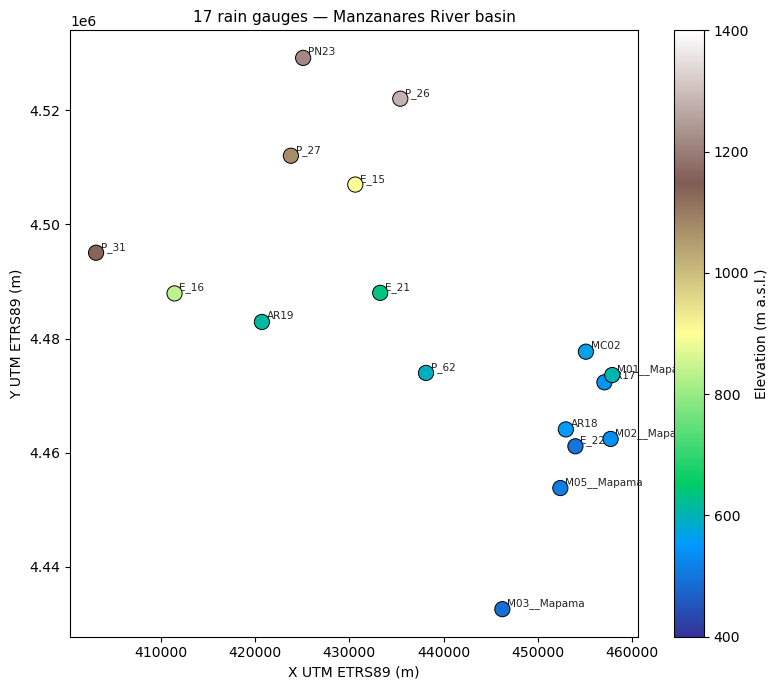

In [2]:
stations = pd.read_csv(STATIONS_DIR / 'stations.csv', index_col=0)
stations.columns = ['X', 'Y', 'Z']
print(f'Stations: {len(stations)}')
print(stations.to_string())

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(stations['X'], stations['Y'], c=stations['Z'],
                cmap='terrain', vmin=400, vmax=1400,
                s=120, edgecolors='k', linewidths=0.7, zorder=5)
plt.colorbar(sc, ax=ax, label='Elevation (m a.s.l.)')
for name, row in stations.iterrows():
    ax.annotate(name, (row['X']+500, row['Y']+500), fontsize=7.5, color='#222')
ax.set_xlabel('X UTM ETRS89 (m)'); ax.set_ylabel('Y UTM ETRS89 (m)')
ax.set_title('17 rain gauges — Manzanares River basin', fontsize=11)
plt.tight_layout(); plt.show()

## 2. Elevation–rainfall relationship

A significant linear relationship exists between station elevation and mean annual rainfall, which is used as an external drift variable in kriging spatial interpolation (Figure 4 in Navas et al., 2024).

Synthetic selected events: 1,000  |  Columns: 84


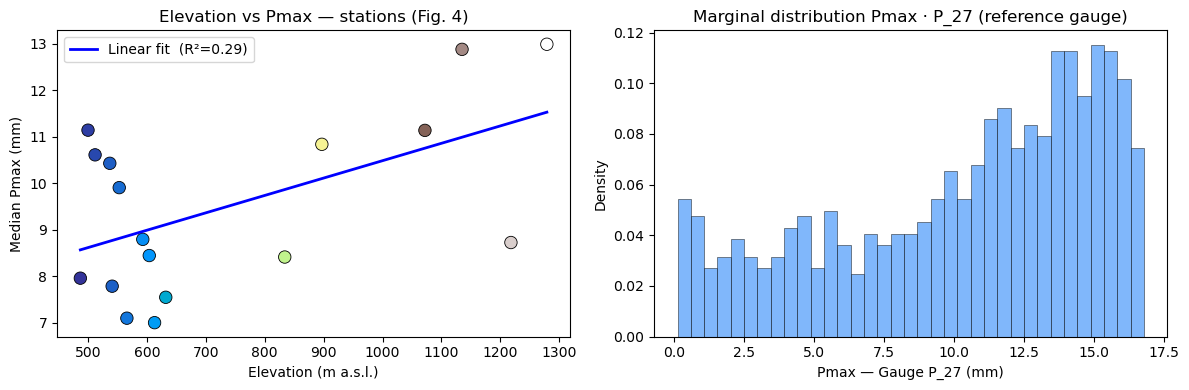

In [3]:
events = pd.read_csv(EVENTS_DIR / 'events_selected.csv', index_col=0)
print(f'Synthetic selected events: {len(events):,}  |  Columns: {events.shape[1]}')

pmax_cols = [f'Pmax{i}' for i in range(1, N_STAT+1)]

# Median Pmax per station vs elevation
pmax_median = events[pmax_cols].median()
pmax_median.index = range(1, N_STAT+1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

z = stations['Z'].values
p = pmax_median.values
fit = np.polyfit(z, p, 1)
zx  = np.linspace(z.min(), z.max(), 100)
r2  = np.corrcoef(z, p)[0, 1]**2

axes[0].scatter(z, p, c=z, cmap='terrain', s=80, edgecolors='k', lw=0.6)
axes[0].plot(zx, np.polyval(fit, zx), 'b-', lw=2,
             label=f'Linear fit  (R²={r2:.2f})')
axes[0].set_xlabel('Elevation (m a.s.l.)'); axes[0].set_ylabel('Median Pmax (mm)')
axes[0].set_title('Elevation vs Pmax — stations (Fig. 4)')
axes[0].legend()

# Marginal distribution for gauge P_27 (station 1 — reference gauge in the paper)
data_p27 = events['Pmax1'].values
data_p27 = data_p27[data_p27 > 0]
axes[1].hist(data_p27, bins=35, color='#60a5fa', alpha=0.8,
             edgecolor='k', lw=0.4, density=True)
axes[1].set_xlabel('Pmax — Gauge P_27 (mm)')
axes[1].set_ylabel('Density')
axes[1].set_title('Marginal distribution Pmax · P_27 (reference gauge)')
plt.tight_layout(); plt.show()

## 3. The four event parameters per gauge

Each event at each gauge is characterised by: **Pmax**, **Pmed**, **Duration** (hours), and **Type** (hyetograph shape index from PCA + K-Means classification).

Summary statistics — P_27 (Pmax > 0):
         Pmax    Pmed  Duration    Type
count  930.00  930.00    930.00  930.00
mean    10.37    1.56     93.94    9.05
std      4.73    0.89     52.22    8.29
min      0.12    0.00      1.13    0.00
25%      6.93    0.84     52.85    1.00
50%     11.56    1.58     90.37    7.00
75%     14.27    2.19    132.99   17.00
max     16.79    4.66    224.06   24.00


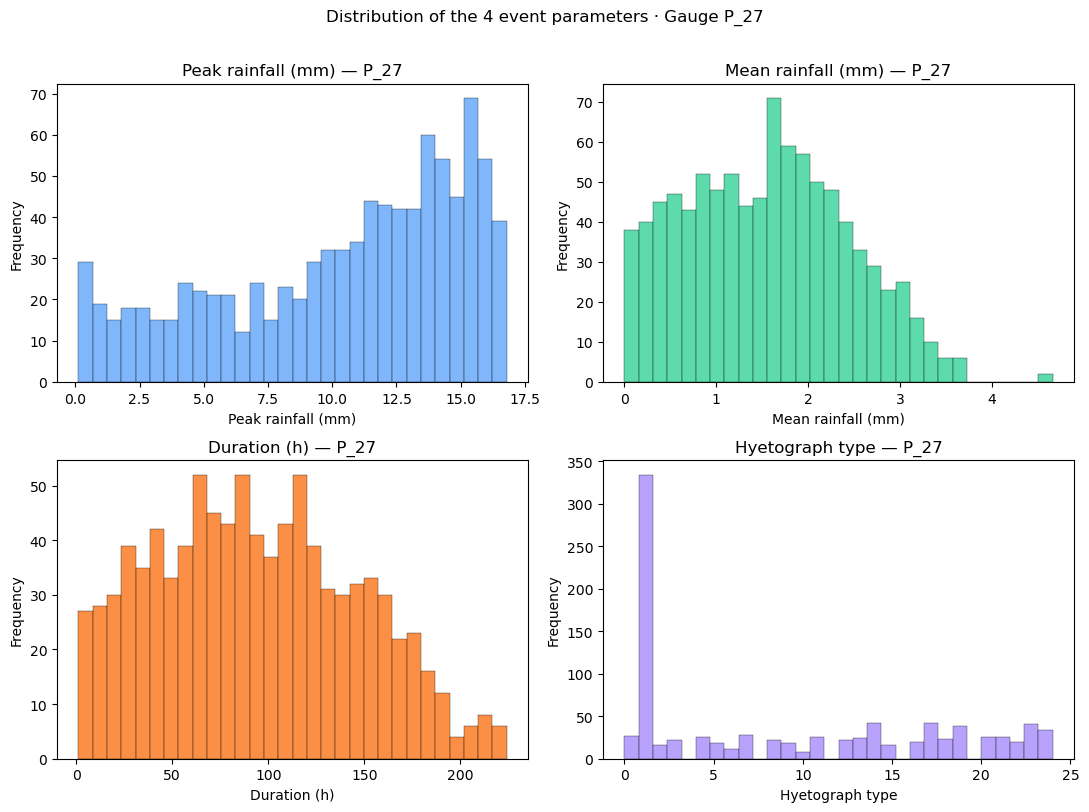

In [4]:
# Reference gauge: P_27 (station 1)
p27 = events[['Pmax1','Pmed1','Duracion1','Tipo1']].copy()
p27 = p27[p27['Pmax1'] > 0].reset_index(drop=True)
p27.columns = ['Pmax','Pmed','Duration','Type']

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

params  = [('Pmax','Peak rainfall (mm)'), ('Pmed','Mean rainfall (mm)'),
           ('Duration','Duration (h)'),   ('Type','Hyetograph type')]
colors  = ['#60a5fa','#34d399','#f97316','#a78bfa']

for ax, (col, label), c in zip(axes, params, colors):
    ax.hist(p27[col], bins=30, color=c, alpha=0.8, edgecolor='k', lw=0.3)
    ax.set_xlabel(label); ax.set_ylabel('Frequency')
    ax.set_title(f'{label} — P_27')

plt.suptitle('Distribution of the 4 event parameters · Gauge P_27', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print('Summary statistics — P_27 (Pmax > 0):')
print(p27.describe().round(2))